# NAB Dataset — EDA & Preprocessing
**Numenta Anomaly Benchmark** · 58 univariate real-world IoT time-series  
IT metrics · industrial sensors · traffic · advertising exchange data

**Pipeline:** Load → Label mapping → EDA → Chronological/Anomaly-Aware Split (per file) → Normalize → Sliding Window → Push to HF Hub

> Part of: *Uncertainty Estimation for Anomaly Detection in IoT Data*

---
## Section 1 — Setup & Data Loading

In [ ]:
# Install dependencies
%pip install -q -r requirements.txt

In [1]:
# ── Configuration — edit these before running ───────────────────────────────
WINDOW_SIZE    = 50      # sliding window length (timesteps)
STEP_SIZE      = 1       # stride between windows
TRAIN_RATIO    = 0.70    # fraction of normal samples for training
VAL_RATIO      = 0.10    # fraction of normal samples for validation
# test = remaining 20% normal + ALL anomalies

# When True, fit a separate MinMaxScaler per file (recommended for NAB
# because each series has a different value range)
SPLIT_PER_FILE = True

# HF_USERNAME and HF_TOKEN are loaded from .env (see imports cell below)
HF_REPO_NAME   = "nab-anomaly-detection"

NAB_REPO_URL   = "https://github.com/numenta/NAB.git"
NAB_DIR        = "NAB"
DATA_DIR       = f"{NAB_DIR}/data"
LABELS_FILE    = f"{NAB_DIR}/labels/combined_windows.json"
OUTPUT_DIR     = "outputs"
NPY_DIR        = "npy_nab"

VALUE_COL      = "value"     # the single sensor column in each NAB CSV
LABEL_COL      = "anomaly"   # column we will create
TIMESTAMP_COL  = "timestamp"

# The six canonical NAB categories used for representative EDA plots
NAB_CATEGORIES = [
    "artificialNoAnomaly",
    "artificialWithAnomaly",
    "realAdExchange",
    "realAWSCloudwatch",
    "realKnownCause",
    "realTraffic",
]

In [2]:
import os
import subprocess
import glob
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from dotenv import load_dotenv
from sklearn.preprocessing import MinMaxScaler
from datasets import Dataset, DatasetDict

# Load HF credentials from .env
load_dotenv()
HF_USERNAME = os.getenv("HF_USERNAME")
HF_TOKEN    = os.getenv("HF_TOKEN")

if not HF_USERNAME or not HF_TOKEN:
    raise EnvironmentError(
        "HF_USERNAME or HF_TOKEN not found. "
        "Add them to your .env file in this directory."
    )

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(NPY_DIR,    exist_ok=True)

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print(f"seaborn {sns.__version__}")
print(f"HF_USERNAME loaded: {HF_USERNAME}")

/Users/ayyoubsoullami/Cooking/ad_iot/.venv_ad_iot/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas  3.0.3
numpy   2.4.5
seaborn 0.13.2
HF_USERNAME loaded: ayyoubsoullami


### 1.1 Clone NAB repository

If you already have the data locally, update `NAB_DIR` in the config cell and skip the next cell.

In [3]:
if not os.path.exists(NAB_DIR):
    print("Cloning NAB repository (this may take a moment) …")
    result = subprocess.run(
        ["git", "clone", "--depth", "1", NAB_REPO_URL, NAB_DIR],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("STDERR:", result.stderr)
        raise RuntimeError("Git clone failed — check your network connection.")
    print("Done.")
else:
    print(f"'{NAB_DIR}' already exists — skipping clone.")

Cloning NAB repository (this may take a moment) …
Done.


### 1.2 Load anomaly window labels from JSON

In [4]:
with open(LABELS_FILE) as f:
    combined_windows: dict = json.load(f)

print(f"Label entries : {len(combined_windows)}")
# Each key is a relative path, e.g. 'realKnownCause/ambient_temperature_system_failure.csv'
# Each value is a list of [start_timestamp, end_timestamp] window pairs
example_label_key = list(combined_windows.keys())[0]
print(f"\nExample entry — {example_label_key}:")
print(combined_windows[example_label_key])

Label entries : 58

Example entry — artificialNoAnomaly/art_daily_no_noise.csv:
[]


### 1.3 Load all 58 CSV files and map anomaly windows to binary labels

In [5]:
def assign_anomaly_labels(df: pd.DataFrame, windows: list) -> pd.Series:
    """Return a binary anomaly series for df given a list of [start, end] windows."""
    labels = np.zeros(len(df), dtype=np.int8)
    for win in windows:
        t_start = pd.Timestamp(win[0])
        t_end   = pd.Timestamp(win[1])
        mask    = (df.index >= t_start) & (df.index <= t_end)
        labels[mask] = 1
    return pd.Series(labels, index=df.index, name=LABEL_COL)


csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True))
print(f"Found {len(csv_paths)} CSV files")

raw_data: dict = {}     # key = 'category/filename.csv'
load_errors   = []

for path in csv_paths:
    rel_key = os.path.relpath(path, DATA_DIR)   # e.g. 'realKnownCause/foo.csv'

    try:
        df = pd.read_csv(path, parse_dates=[TIMESTAMP_COL],
                         index_col=TIMESTAMP_COL)
        df.index = pd.to_datetime(df.index, utc=False)
        df = df.sort_index()

        # Map anomaly windows; default to all-normal if key not in label file
        windows = combined_windows.get(rel_key, [])
        df[LABEL_COL] = assign_anomaly_labels(df, windows)

        raw_data[rel_key] = df
    except Exception as e:
        load_errors.append((rel_key, str(e)))

print(f"\nSuccessfully loaded : {len(raw_data)} files")
if load_errors:
    print(f"Load errors         : {len(load_errors)}")
    for k, err in load_errors:
        print(f"  {k}: {err}")

Found 58 CSV files

Successfully loaded : 58 files


In [6]:
# Inspect one example file
ex_key = list(raw_data.keys())[0]
ex_df  = raw_data[ex_key]

print(f"=== {ex_key} ===")
print(f"Shape      : {ex_df.shape}")
print(f"dtypes:\n{ex_df.dtypes}")
print(f"\nAnomaly windows : {combined_windows.get(ex_key, [])}")
print(f"Anomaly count   : {ex_df[LABEL_COL].sum()}")
display(ex_df.head())

=== artificialNoAnomaly/art_daily_no_noise.csv ===
Shape      : (4032, 2)
dtypes:
value      float64
anomaly       int8
dtype: object

Anomaly windows : []
Anomaly count   : 0


,value,anomaly
timestamp,,
2014-04-01 00:00:00,20.0,0
2014-04-01 00:05:00,20.0,0
2014-04-01 00:10:00,20.0,0
2014-04-01 00:15:00,20.0,0
2014-04-01 00:20:00,20.0,0


---
## Section 2 — Exploratory Data Analysis

### 2.0 Data-type audit

In [7]:
non_numeric_flags = {}
for key, df in raw_data.items():
    if not pd.api.types.is_numeric_dtype(df[VALUE_COL]):
        non_numeric_flags[key] = VALUE_COL

if non_numeric_flags:
    print("Non-numeric value columns detected:")
    for k, col in non_numeric_flags.items():
        print(f"  {k}: {col}")
else:
    print(f"'{VALUE_COL}' column is numeric in all {len(raw_data)} files.")

'value' column is numeric in all 58 files.


### 2.1 Six representative time-series (one per NAB category)

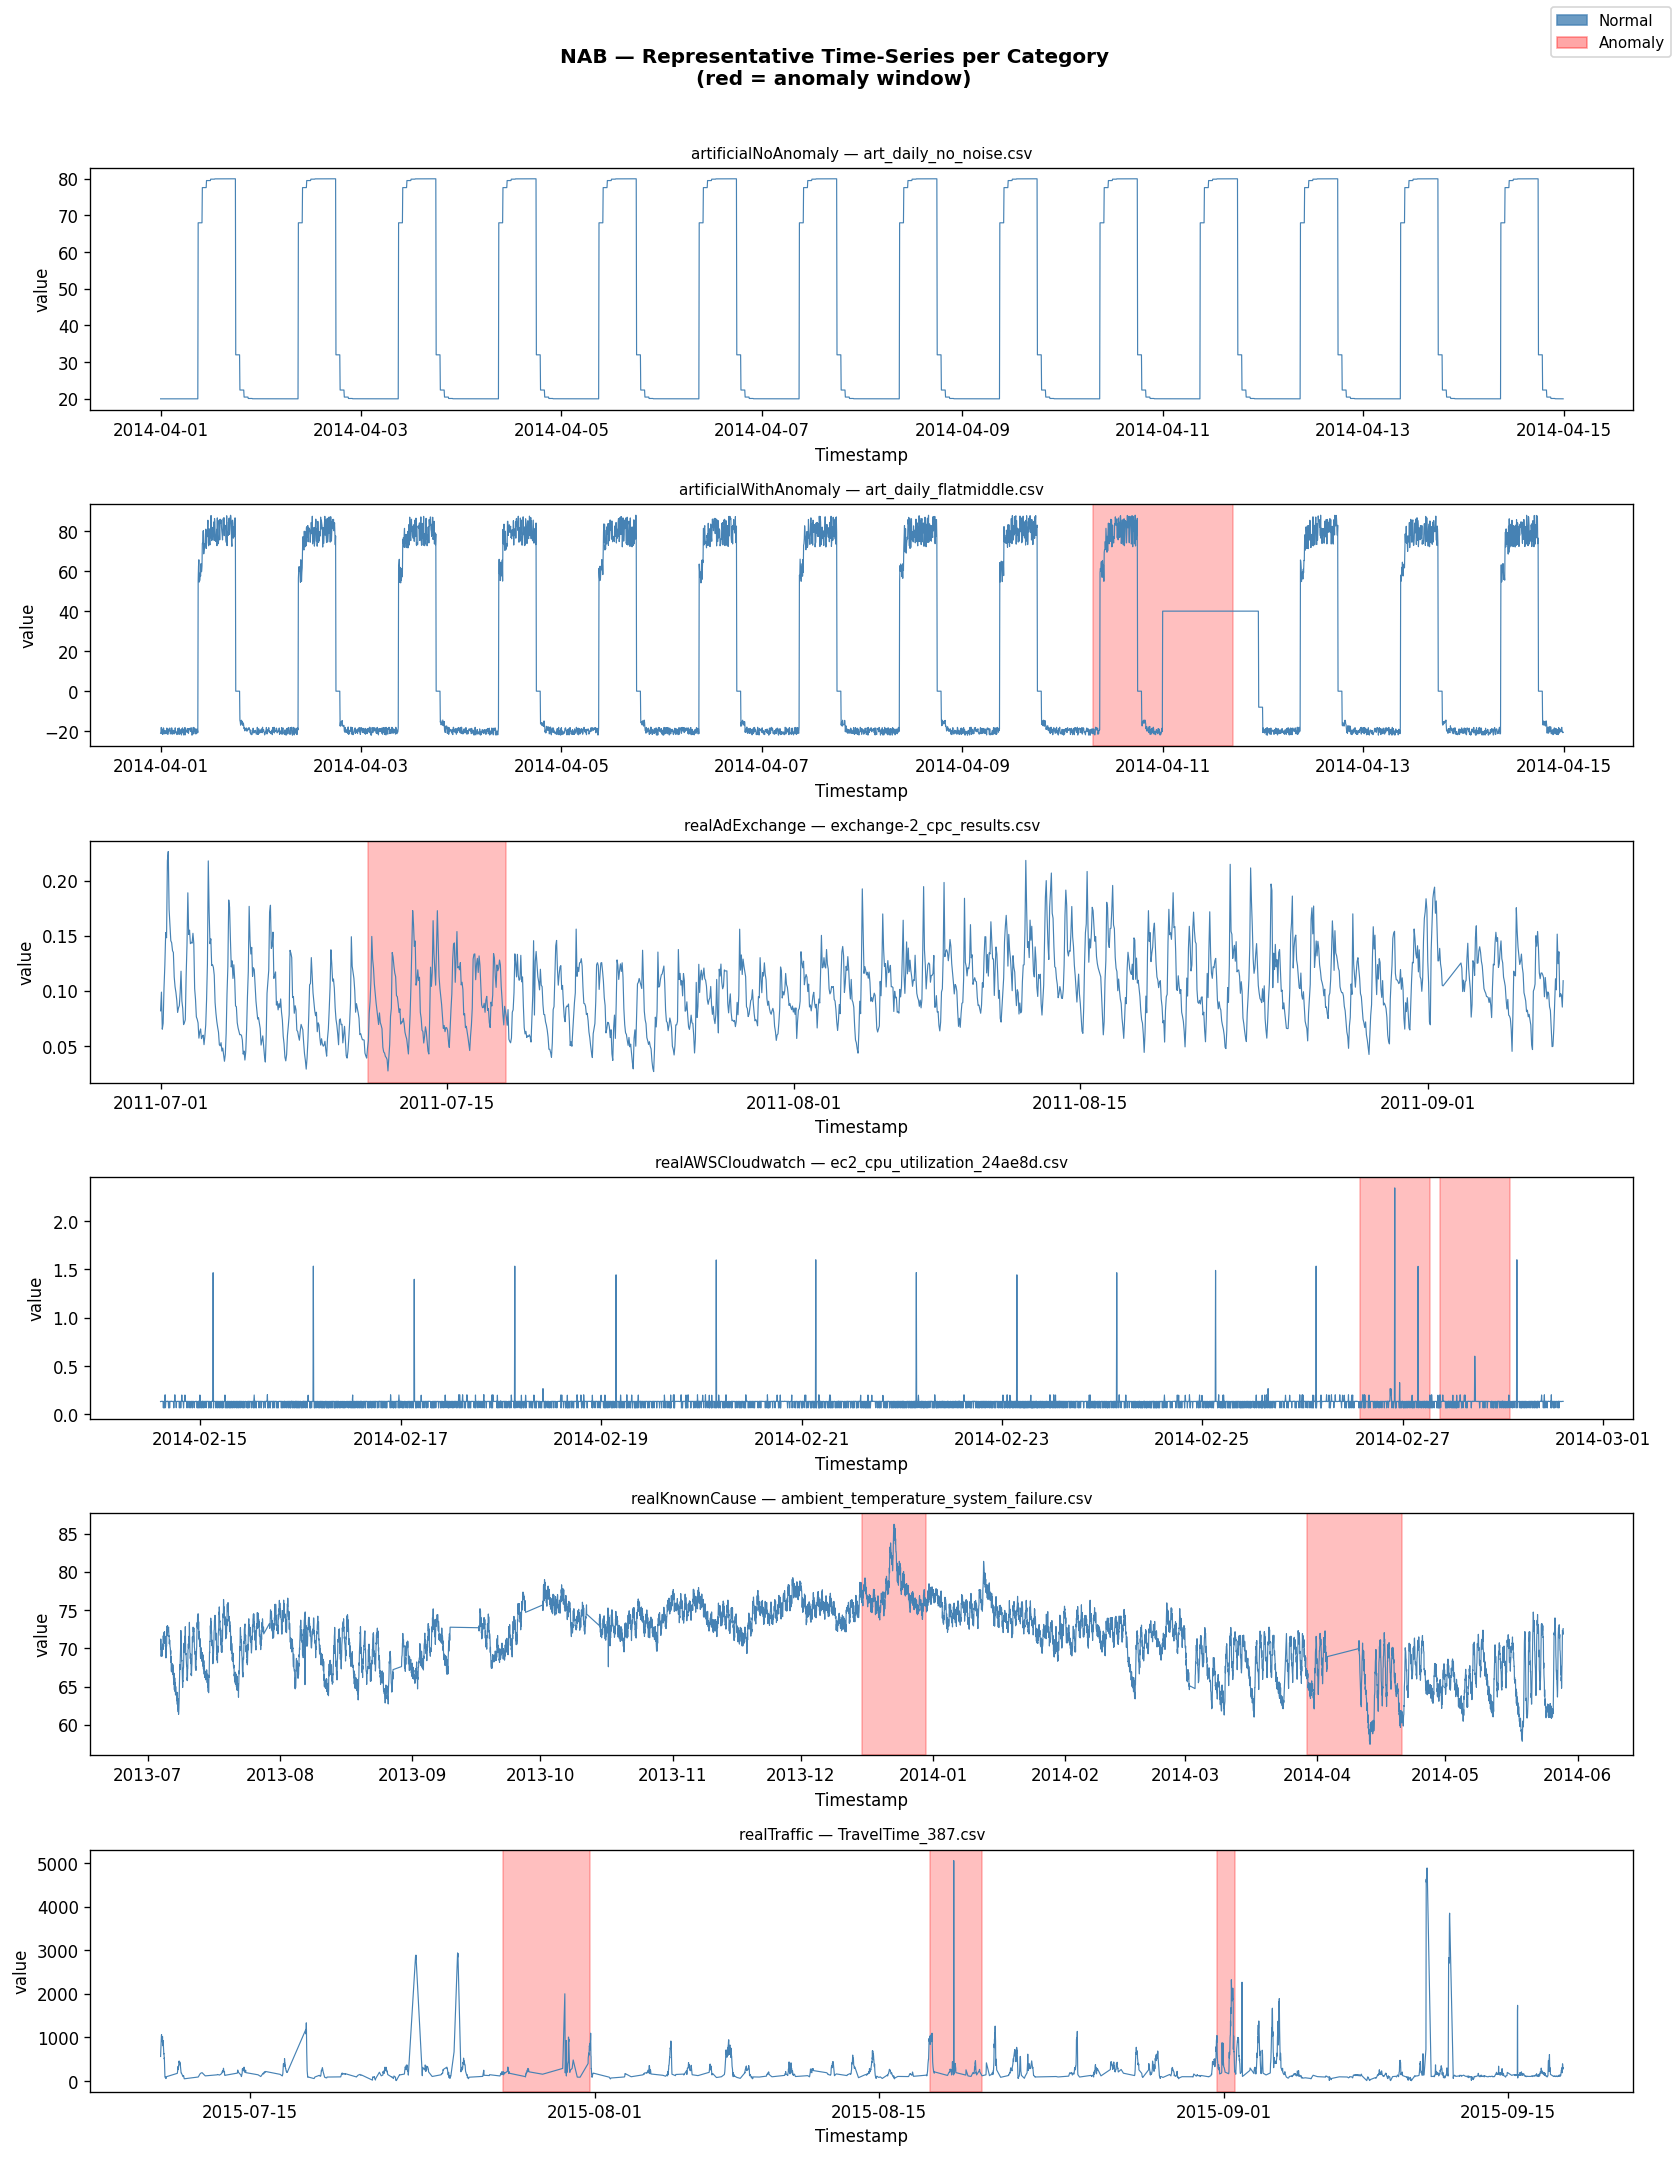

In [8]:
def shade_anomalies(ax, df, label_col=LABEL_COL, color="red", alpha=0.25):
    """Shade contiguous anomaly spans on a matplotlib axis."""
    labels  = df[label_col].values
    idx     = df.index
    in_anom = False
    start   = None
    for i, v in enumerate(labels):
        if v == 1 and not in_anom:
            start   = idx[i]
            in_anom = True
        elif v == 0 and in_anom:
            ax.axvspan(start, idx[i - 1], color=color, alpha=alpha)
            in_anom = False
    if in_anom:
        ax.axvspan(start, idx[-1], color=color, alpha=alpha)


# Pick one representative file per category
rep_files = {}
for cat in NAB_CATEGORIES:
    candidates = [k for k in raw_data if k.startswith(cat + "/")]
    if candidates:
        # Prefer a file that actually has anomalies for visual richness
        with_anom = [c for c in candidates if raw_data[c][LABEL_COL].sum() > 0]
        rep_files[cat] = with_anom[0] if with_anom else candidates[0]

n_rep  = len(rep_files)
fig, axes = plt.subplots(n_rep, 1, figsize=(14, 3 * n_rep), sharex=False)
if n_rep == 1:
    axes = [axes]

fig.suptitle("NAB — Representative Time-Series per Category\n(red = anomaly window)",
             fontsize=12, fontweight="bold")

for ax, (cat, key) in zip(axes, rep_files.items()):
    df = raw_data[key]
    ax.plot(df.index, df[VALUE_COL], linewidth=0.7, color="steelblue")
    shade_anomalies(ax, df)
    ax.set_title(f"{cat} — {os.path.basename(key)}", fontsize=9)
    ax.set_ylabel(VALUE_COL)
    ax.set_xlabel("Timestamp")

anom_patch = mpatches.Patch(color="red",       alpha=0.35, label="Anomaly")
norm_patch = mpatches.Patch(color="steelblue", alpha=0.80, label="Normal")
fig.legend(handles=[norm_patch, anom_patch], loc="upper right", fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f"{OUTPUT_DIR}/nab_representative_timeseries.png", bbox_inches="tight")
plt.show()

### 2.2 Anomaly percentage per file (horizontal bar chart, sorted)

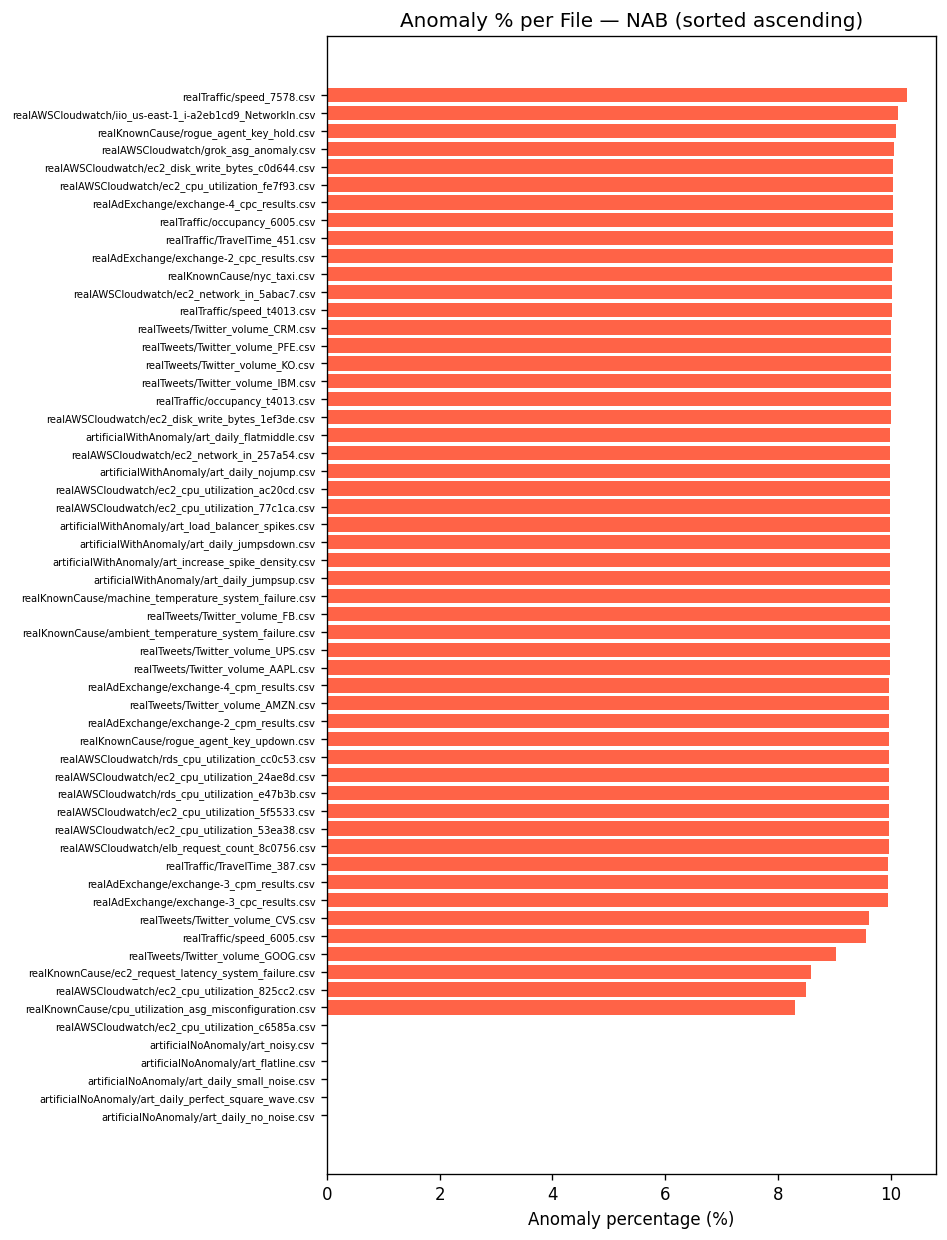

In [9]:
anom_pct_list = []
for key, df in raw_data.items():
    n_total = len(df)
    n_anom  = int(df[LABEL_COL].sum())
    anom_pct_list.append({
        "file"      : key,
        "n_total"   : n_total,
        "n_anomaly" : n_anom,
        "anom_pct"  : 100 * n_anom / n_total if n_total > 0 else 0.0,
    })

pct_df = pd.DataFrame(anom_pct_list).sort_values("anom_pct")

fig, ax = plt.subplots(figsize=(8, max(6, len(pct_df) * 0.18)))
colors  = ["tomato" if p > 0 else "steelblue" for p in pct_df["anom_pct"]]
ax.barh(pct_df["file"], pct_df["anom_pct"], color=colors)
ax.set_xlabel("Anomaly percentage (%)")
ax.set_title("Anomaly % per File — NAB (sorted ascending)")
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/nab_anomaly_pct_per_file.png", bbox_inches="tight")
plt.show()

### 2.3 Distribution of series lengths across all 58 files

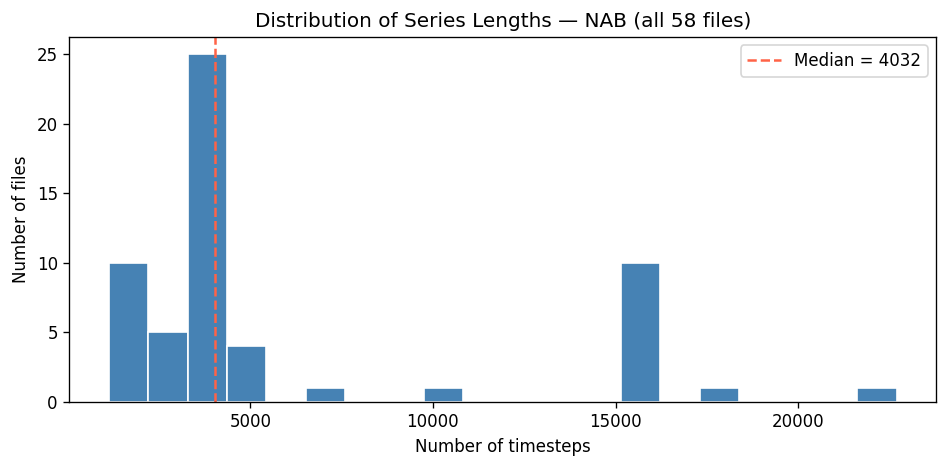

Min length : 1,127
Max length : 22,695
Median     : 4,032


In [10]:
lengths = [len(df) for df in raw_data.values()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=20, color="steelblue", edgecolor="white")
ax.axvline(np.median(lengths), color="tomato", linestyle="--",
           linewidth=1.5, label=f"Median = {int(np.median(lengths))}")
ax.set_xlabel("Number of timesteps")
ax.set_ylabel("Number of files")
ax.set_title("Distribution of Series Lengths — NAB (all 58 files)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/nab_series_length_distribution.png", bbox_inches="tight")
plt.show()

print(f"Min length : {min(lengths):,}")
print(f"Max length : {max(lengths):,}")
print(f"Median     : {int(np.median(lengths)):,}")

### 2.4 Value distributions for 3 representative files (normal vs anomalous overlay)

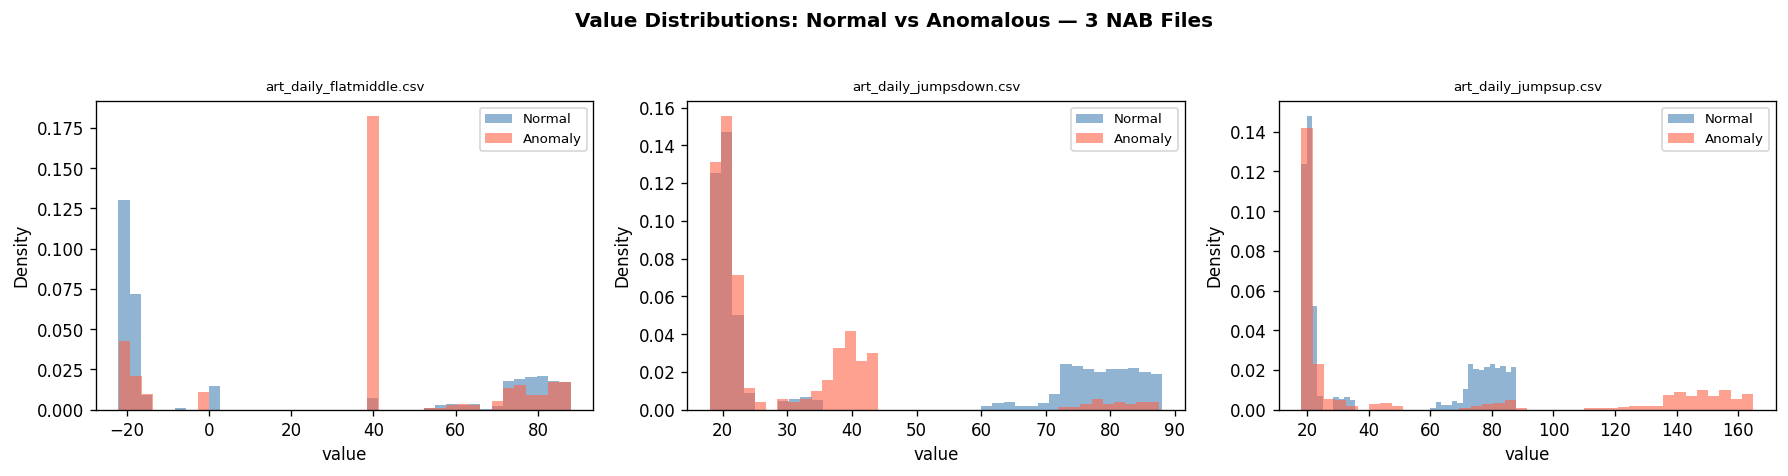

In [11]:
# Pick 3 files that have anomalies for meaningful comparison
files_with_anom = [k for k, d in raw_data.items() if d[LABEL_COL].sum() > 0][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key in zip(axes, files_with_anom):
    df   = raw_data[key]
    norm = df[df[LABEL_COL] == 0][VALUE_COL].dropna()
    anom = df[df[LABEL_COL] == 1][VALUE_COL].dropna()
    ax.hist(norm, bins=40, alpha=0.6, color="steelblue",
            label="Normal",  density=True)
    ax.hist(anom, bins=40, alpha=0.6, color="tomato",
            label="Anomaly", density=True)
    ax.set_title(os.path.basename(key), fontsize=8)
    ax.set_xlabel(VALUE_COL)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("Value Distributions: Normal vs Anomalous — 3 NAB Files",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{OUTPUT_DIR}/nab_value_distributions.png", bbox_inches="tight")
plt.show()

### 2.5 Overall class balance

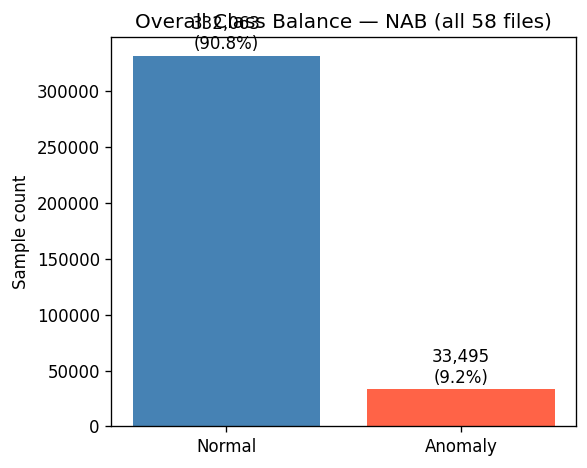


Anomaly rate: 9.16% — do NOT balance this dataset.
Training set will contain normal samples only.
Use F1, AUC-PR as evaluation metrics.


In [12]:
all_labels = pd.concat([d[LABEL_COL] for d in raw_data.values()])
total      = len(all_labels)
n_normal   = int((all_labels == 0).sum())
n_anomaly  = int((all_labels == 1).sum())
anom_pct   = 100 * n_anomaly / total

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Normal", "Anomaly"], [n_normal, n_anomaly],
              color=["steelblue", "tomato"])
for bar, count, pct in zip(bars,
                            [n_normal, n_anomaly],
                            [100 - anom_pct, anom_pct]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f"{count:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Sample count")
ax.set_title("Overall Class Balance — NAB (all 58 files)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/nab_class_balance.png", bbox_inches="tight")
plt.show()

print(f"\nAnomaly rate: {anom_pct:.2f}% — do NOT balance this dataset.")
print("Training set will contain normal samples only.")
print("Use F1, AUC-PR as evaluation metrics.")

> **Why we do NOT balance this dataset**
>
> NAB anomaly detection is framed as **unsupervised reconstruction-based** learning (autoencoder).
> The model sees only normal operating patterns during training and flags deviations at inference time.
>
> Applying SMOTE, oversampling, or undersampling would:
> 1. Expose anomaly signatures to the training process, breaking the unsupervised assumption.
> 2. Create artificial symmetry that does not reflect real deployment conditions.
> 3. Make accuracy a misleading metric (a trivial majority classifier scores well on a balanced set).
>
> Correct evaluation metrics: **F1-score** and **AUC-PR** (precision-recall area under the curve).

### 2.6 Overall summary

In [13]:
print(f"Total files          : {len(raw_data)}")
print(f"Total timesteps      : {total:,}")
print(f"Overall anomaly rate : {anom_pct:.2f}%")
print(f"Min series length    : {min(lengths):,}")
print(f"Max series length    : {max(lengths):,}")
print(f"Median series length : {int(np.median(lengths)):,}")

Total files          : 58
Total timesteps      : 365,558
Overall anomaly rate : 9.16%
Min series length    : 1,127
Max series length    : 22,695
Median series length : 4,032


---
## Section 3 — Preprocessing

### 3.1 Helper functions

In [14]:
def chronological_split(df: pd.DataFrame, train_ratio: float, val_ratio: float):
    """Split a DataFrame chronologically, anomaly-aware.

    Train/val contain only normal samples. Test = tail normal + all anomalies.
    Returns (train_df, val_df, test_df).
    """
    normal = df[df[LABEL_COL] == 0].copy()
    anom   = df[df[LABEL_COL] == 1].copy()

    n = len(normal)
    te = int(n * train_ratio)
    ve = int(n * (train_ratio + val_ratio))

    train = normal.iloc[:te]
    val   = normal.iloc[te:ve]
    test  = pd.concat([normal.iloc[ve:], anom]).sort_index()
    return train, val, test


def sliding_window(X: np.ndarray, y: np.ndarray,
                   window_size: int, step_size: int):
    """Segment a 1-D or 2-D time-series into overlapping windows.

    Returns:
        X_win : (n_windows, window_size) for 1-D input
               (n_windows, window_size, n_features) for 2-D input
        y_win : (n_windows,)  1 if any step in the window is anomalous
    """
    windows_X, windows_y = [], []
    n = len(X)
    for start in range(0, n - window_size + 1, step_size):
        end = start + window_size
        windows_X.append(X[start:end])
        windows_y.append(int(y[start:end].any()))
    if not windows_X:
        shape = (0, window_size) if X.ndim == 1 else (0, window_size, X.shape[1])
        return np.empty(shape, dtype=np.float32), np.empty((0,), dtype=np.int8)
    return (np.array(windows_X, dtype=np.float32),
            np.array(windows_y, dtype=np.int8))

### 3.2 Missing values + timestamp parsing

In [15]:
nan_summary = {}
for key, df in raw_data.items():
    n_nan = df[VALUE_COL].isna().sum()
    if n_nan > 0:
        nan_summary[key] = n_nan
        # Forward-fill, then drop any remaining gaps
        df[VALUE_COL] = df[VALUE_COL].ffill().bfill()
        raw_data[key] = df.dropna(subset=[VALUE_COL])

if nan_summary:
    print(f"Files with NaNs ({len(nan_summary)}):")
    for k, n in nan_summary.items():
        print(f"  {k}: {n} NaNs")
else:
    print("No NaN values found in any file.")

No NaN values found in any file.


### 3.3 Chronological + anomaly-aware split with per-file MinMaxScaler

`SPLIT_PER_FILE = True` fits a dedicated scaler per file, respecting that each
NAB series can have an entirely different value range.

In [16]:
train_windows_list, train_labels_list = [], []
val_windows_list,   val_labels_list   = [], []
test_windows_list,  test_labels_list  = [], []

per_file_stats = []

for key, df in raw_data.items():
    train_df, val_df, test_df = chronological_split(df, TRAIN_RATIO, VAL_RATIO)

    if len(train_df) < WINDOW_SIZE:
        # Skip files too short to produce a single window — note the skip
        per_file_stats.append({
            "file": key, "skipped": True,
            "n_train_windows": 0, "n_val_windows": 0, "n_test_windows": 0,
            "anomaly_rate_test": 0.0,
        })
        continue

    # Fit scaler on this file's training slice only
    scaler = MinMaxScaler()
    train_vals = scaler.fit_transform(train_df[[VALUE_COL]]).ravel()
    val_vals   = scaler.transform(val_df[[VALUE_COL]]).ravel()   if len(val_df)  > 0 else np.array([])
    test_vals  = scaler.transform(test_df[[VALUE_COL]]).ravel()  if len(test_df) > 0 else np.array([])

    train_lbl  = train_df[LABEL_COL].values.astype(np.int8)
    val_lbl    = val_df[LABEL_COL].values.astype(np.int8)   if len(val_df)  > 0 else np.array([], dtype=np.int8)
    test_lbl   = test_df[LABEL_COL].values.astype(np.int8)  if len(test_df) > 0 else np.array([], dtype=np.int8)

    Xtr, ytr = sliding_window(train_vals.reshape(-1, 1), train_lbl, WINDOW_SIZE, STEP_SIZE)
    Xva, yva = sliding_window(val_vals.reshape(-1, 1),   val_lbl,   WINDOW_SIZE, STEP_SIZE) if len(val_vals) >= WINDOW_SIZE   else (np.empty((0, WINDOW_SIZE, 1), dtype=np.float32), np.empty((0,), dtype=np.int8))
    Xte, yte = sliding_window(test_vals.reshape(-1, 1),  test_lbl,  WINDOW_SIZE, STEP_SIZE) if len(test_vals) >= WINDOW_SIZE  else (np.empty((0, WINDOW_SIZE, 1), dtype=np.float32), np.empty((0,), dtype=np.int8))

    train_windows_list.append(Xtr);  train_labels_list.append(ytr)
    val_windows_list.append(Xva);    val_labels_list.append(yva)
    test_windows_list.append(Xte);   test_labels_list.append(yte)

    per_file_stats.append({
        "file"              : key,
        "skipped"           : False,
        "n_train_windows"   : int(Xtr.shape[0]),
        "n_val_windows"     : int(Xva.shape[0]),
        "n_test_windows"    : int(Xte.shape[0]),
        "anomaly_rate_test" : float(round(yte.mean(), 4)) if len(yte) > 0 else 0.0,
    })

# Concatenate across all files
X_train = np.concatenate(train_windows_list, axis=0)
X_val   = np.concatenate(val_windows_list,   axis=0)
X_test  = np.concatenate(test_windows_list,  axis=0)
y_train = np.concatenate(train_labels_list,  axis=0)
y_val   = np.concatenate(val_labels_list,    axis=0)
y_test  = np.concatenate(test_labels_list,   axis=0)

print("Final concatenated shapes:")
print(f"  X_train : {X_train.shape}  y_train anomalies : "
      f"{y_train.sum()} ({100*y_train.mean():.2f}%)")
print(f"  X_val   : {X_val.shape}  y_val anomalies   : "
      f"{y_val.sum()} ({100*y_val.mean():.2f}%)")
print(f"  X_test  : {X_test.shape}  y_test anomalies  : "
      f"{y_test.sum()} ({100*y_test.mean():.2f}%)")

Final concatenated shapes:
  X_train : (229577, 50, 1)  y_train anomalies : 0 (0.00%)
  X_val   : (30354, 50, 1)  y_val anomalies   : 0 (0.00%)
  X_test  : (97101, 50, 1)  y_test anomalies  : 34524 (35.55%)


### 3.4 Save numpy arrays locally

In [17]:
for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test),
                  ("y_train", y_train), ("y_val",   y_val), ("y_test",  y_test)]:
    path = os.path.join(NPY_DIR, f"{name}.npy")
    np.save(path, arr)
    print(f"Saved {path}  shape={arr.shape}")

Saved npy_nab/X_train.npy  shape=(229577, 50, 1)
Saved npy_nab/X_val.npy  shape=(30354, 50, 1)
Saved npy_nab/X_test.npy  shape=(97101, 50, 1)
Saved npy_nab/y_train.npy  shape=(229577,)
Saved npy_nab/y_val.npy  shape=(30354,)
Saved npy_nab/y_test.npy  shape=(97101,)


---
## Section 4 — Validation Plots

### 4.1 Split boundaries for 3 representative files

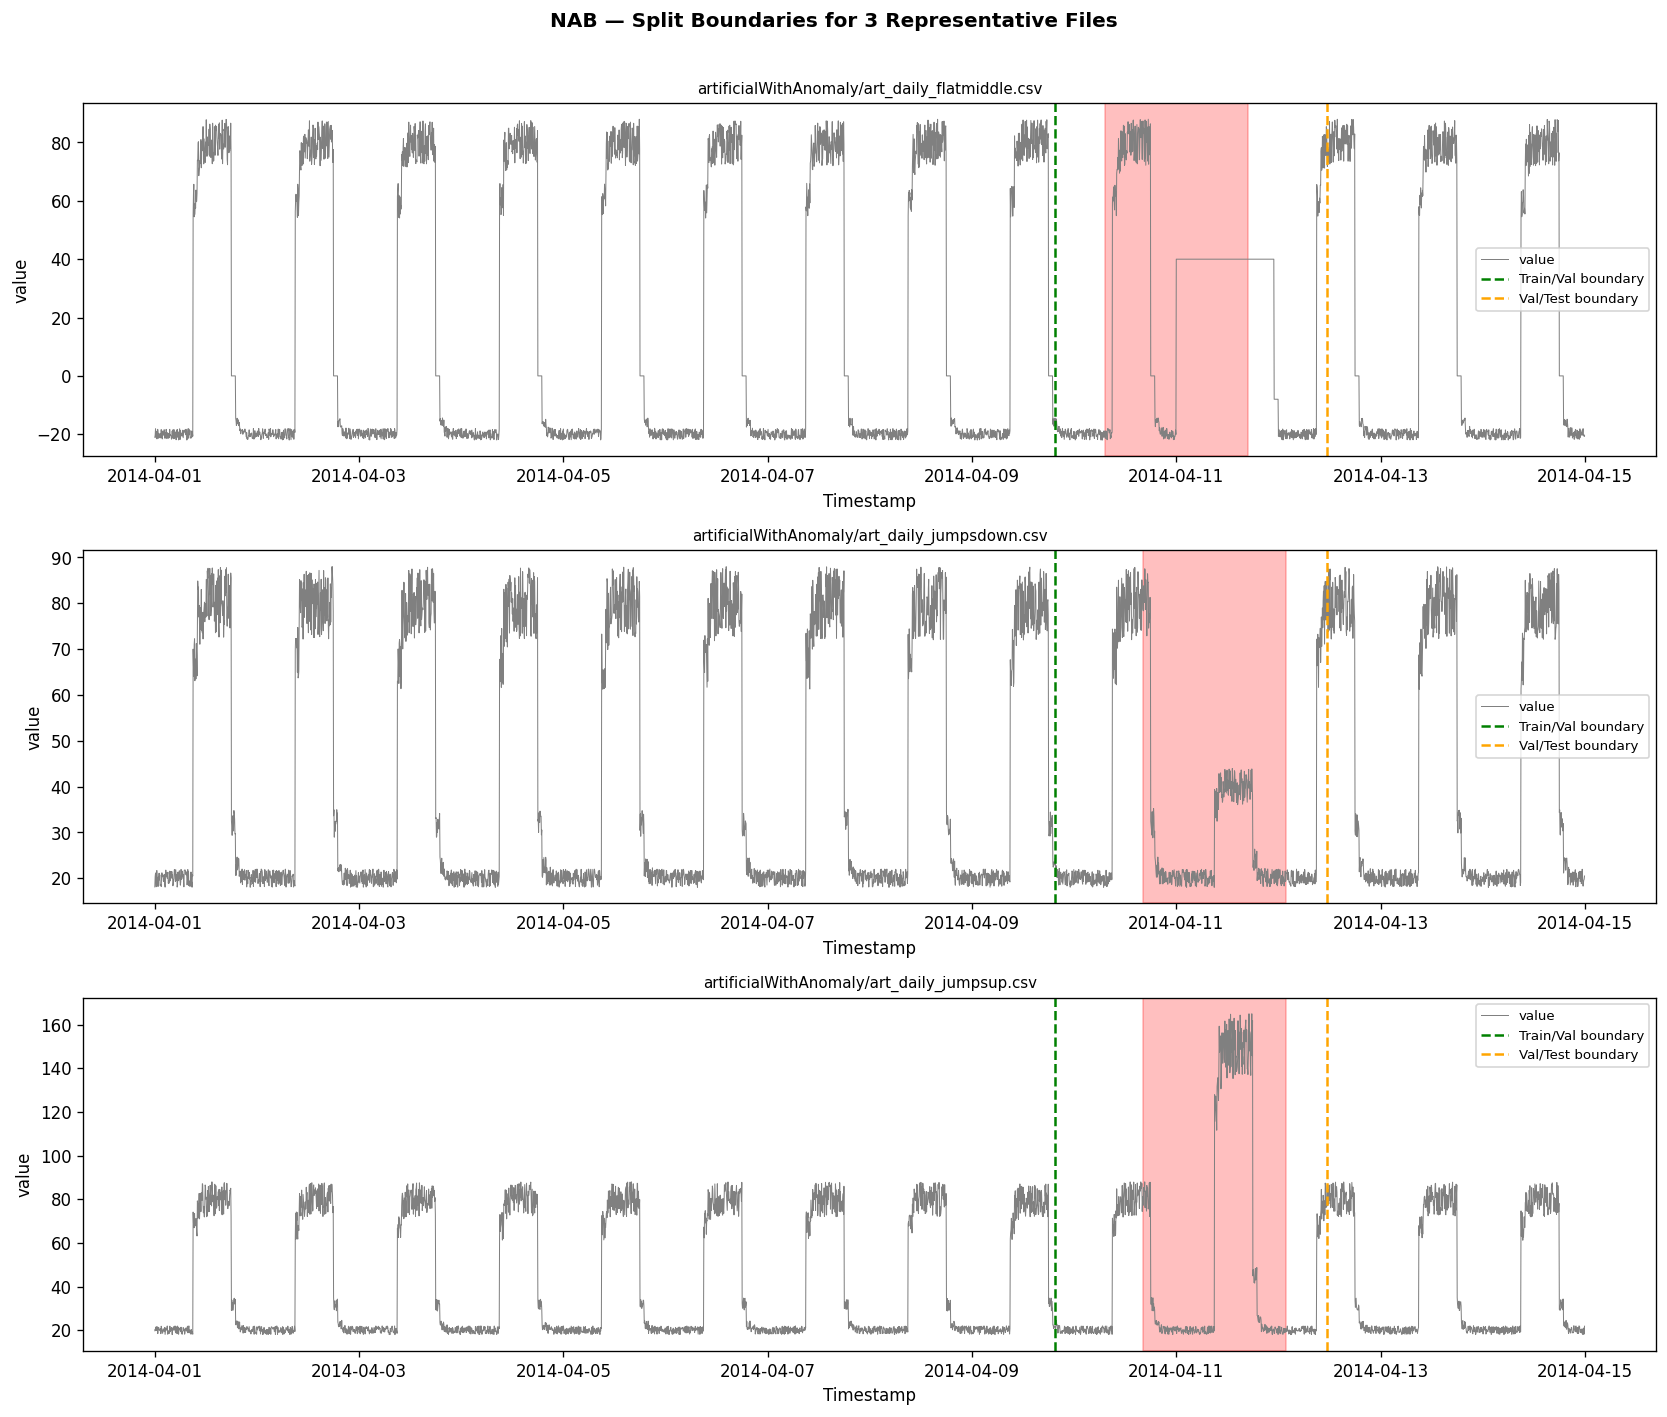

In [18]:
rep_keys = [k for k, d in raw_data.items() if d[LABEL_COL].sum() > 0][:3]

fig, axes = plt.subplots(len(rep_keys), 1, figsize=(14, 4 * len(rep_keys)))
if len(rep_keys) == 1:
    axes = [axes]

for ax, key in zip(axes, rep_keys):
    df = raw_data[key]
    train_s, val_s, test_s = chronological_split(df, TRAIN_RATIO, VAL_RATIO)

    ax.plot(df.index, df[VALUE_COL], linewidth=0.6, color="grey", label=VALUE_COL)
    shade_anomalies(ax, df)

    if len(train_s) > 0:
        ax.axvline(train_s.index[-1], color="green",  linestyle="--", linewidth=1.5,
                   label="Train/Val boundary")
    if len(val_s) > 0:
        ax.axvline(val_s.index[-1],   color="orange", linestyle="--", linewidth=1.5,
                   label="Val/Test boundary")

    ax.set_title(key, fontsize=9)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel(VALUE_COL)
    ax.legend(fontsize=8)

fig.suptitle("NAB — Split Boundaries for 3 Representative Files",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f"{OUTPUT_DIR}/nab_split_boundaries.png", bbox_inches="tight")
plt.show()

### 4.2 Per-file stats summary table

In [20]:
stats_df = pd.DataFrame(per_file_stats).set_index("file")
stats_df["anomaly_rate_test_pct"] = (stats_df["anomaly_rate_test"] * 100).round(2)

display_cols = ["skipped", "n_train_windows",
                "n_val_windows", "n_test_windows", "anomaly_rate_test_pct"]

styled = (
    stats_df[display_cols]
    .rename(columns={"anomaly_rate_test_pct": "test_anom_%"})
    .style
    .background_gradient(subset=["test_anom_%"], cmap="Reds")
    .format({"test_anom_%": "{:.2f}"})
)
display(styled)

# Save as CSV artifact
stats_path = os.path.join(OUTPUT_DIR, "nab_per_file_stats.csv")
stats_df.to_csv(stats_path)
print(f"Saved per-file stats to {stats_path}")

,skipped,n_train_windows,n_val_windows,n_test_windows,test_anom_%
file,,,,,
artificialNoAnomaly/art_daily_no_noise.csv,False,2773,354,758,0.00
artificialNoAnomaly/art_daily_perfect_square_wave.csv,False,2773,354,758,0.00
artificialNoAnomaly/art_daily_small_noise.csv,False,2773,354,758,0.00
artificialNoAnomaly/art_flatline.csv,False,2773,354,758,0.00
artificialNoAnomaly/art_noisy.csv,False,2773,354,758,0.00
artificialWithAnomaly/art_daily_flatmiddle.csv,False,2491,314,1080,37.31
artificialWithAnomaly/art_daily_jumpsdown.csv,False,2491,314,1080,37.31
artificialWithAnomaly/art_daily_jumpsup.csv,False,2491,314,1080,37.31
artificialWithAnomaly/art_daily_nojump.csv,False,2491,314,1080,37.31


Saved per-file stats to outputs/nab_per_file_stats.csv


### 4.3 Distribution of window-level anomaly rates in the test set

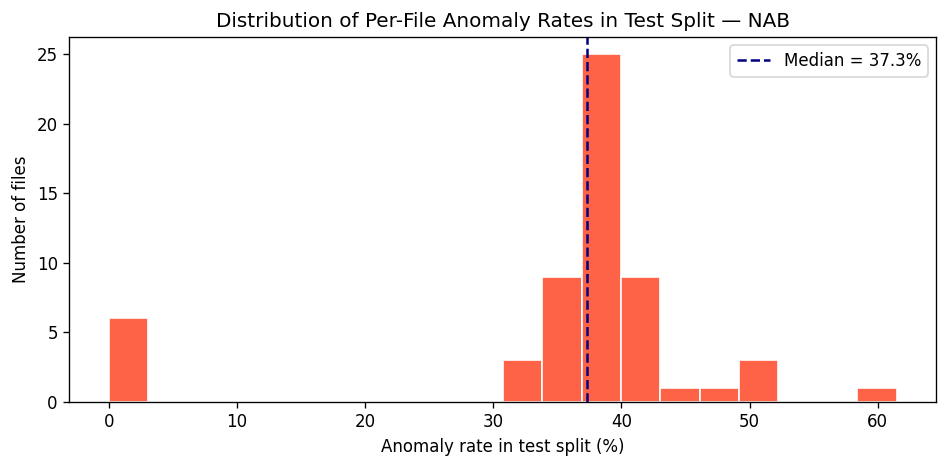

In [21]:
per_file_test_rates = [
    row["anomaly_rate_test"] * 100
    for row in per_file_stats
    if not row["skipped"] and row["n_test_windows"] > 0
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_file_test_rates, bins=20, color="tomato", edgecolor="white")
ax.axvline(np.median(per_file_test_rates), color="navy", linestyle="--",
           linewidth=1.5,
           label=f"Median = {np.median(per_file_test_rates):.1f}%")
ax.set_xlabel("Anomaly rate in test split (%)")
ax.set_ylabel("Number of files")
ax.set_title("Distribution of Per-File Anomaly Rates in Test Split — NAB")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/nab_test_anomaly_rate_distribution.png",
            bbox_inches="tight")
plt.show()

---
## Section 5 — Push to Hugging Face Hub

Set `HF_USERNAME` and `HF_TOKEN` in the configuration cell,  
or authenticate via `huggingface-cli login` in a terminal beforehand.

In [ ]:
def arrays_to_hf_dict(X: np.ndarray, y: np.ndarray) -> dict:
    """Flatten (n_windows, window_size, 1) → HuggingFace-compatible dict.

    NAB is univariate so there is only feature_0.
    """
    n_windows, ws, n_feat = X.shape
    d = {f"feature_{i}": X[:, :, i].tolist() for i in range(n_feat)}
    d["label"] = y.tolist()
    return d


hf_train = Dataset.from_dict(arrays_to_hf_dict(X_train, y_train))
hf_val   = Dataset.from_dict(arrays_to_hf_dict(X_val,   y_val))
hf_test  = Dataset.from_dict(arrays_to_hf_dict(X_test,  y_test))

dataset_dict = DatasetDict({
    "train":      hf_train,
    "validation": hf_val,
    "test":       hf_test,
})
print(dataset_dict)

In [ ]:
metadata = {
    "dataset_name"      : "NAB (Numenta Anomaly Benchmark)",
    "description"       : (
        "58 univariate real-world IoT / IT time-series. "
        "Preprocessed with per-file chronological + anomaly-aware split. "
        "Per-file MinMaxScaler. Sliding window applied after splitting."
    ),
    "value_column"      : VALUE_COL,
    "label_column"      : "label",
    "window_size"       : WINDOW_SIZE,
    "step_size"         : STEP_SIZE,
    "split_per_file"    : SPLIT_PER_FILE,
    "train_ratio"       : TRAIN_RATIO,
    "val_ratio"         : VAL_RATIO,
    "scaler"            : "MinMaxScaler fitted per-file on each file's train split",
    "n_files"           : len(raw_data),
    "n_train_windows"   : int(X_train.shape[0]),
    "n_val_windows"     : int(X_val.shape[0]),
    "n_test_windows"    : int(X_test.shape[0]),
    "anomaly_rate_test" : float(round(float(y_test.mean()), 4)),
    "source"            : "https://github.com/numenta/NAB",
}

meta_path = os.path.join(OUTPUT_DIR, "nab_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to {meta_path}")
print(json.dumps(metadata, indent=2))

In [ ]:
repo_id = f"{HF_USERNAME}/{HF_REPO_NAME}"

dataset_dict.push_to_hub(
    repo_id,
    token=HF_TOKEN,
    commit_message="Add NAB preprocessed sliding-window dataset",
)
print(f"\nDataset pushed to: https://huggingface.co/datasets/{repo_id}")

In [ ]:
# Upload the per-file stats CSV as an additional dataset artifact
from huggingface_hub import HfApi

api = HfApi()
api.upload_file(
    path_or_fileobj=stats_path,
    path_in_repo="nab_per_file_stats.csv",
    repo_id=repo_id,
    repo_type="dataset",
    token=HF_TOKEN,
    commit_message="Add per-file stats metadata CSV",
)
print("Per-file stats CSV uploaded.")

### Loading the dataset in Google Colab

```python
from datasets import load_dataset
import numpy as np

ds = load_dataset("ayyoubsoullami/nab-anomaly-detection")

# Reconstruct numpy arrays (NAB is univariate → n_features = 1)
def split_to_arrays(split, n_features=1):
    # Stack per-feature columns → (n_windows, window_size, n_features)
    X = np.stack(
        [np.array(split[f"feature_{i}"]) for i in range(n_features)],
        axis=-1
    )
    y = np.array(split["label"])
    return X, y

X_train, y_train = split_to_arrays(ds["train"])
X_val,   y_val   = split_to_arrays(ds["validation"])
X_test,  y_test  = split_to_arrays(ds["test"])

print(X_train.shape, X_val.shape, X_test.shape)
# → (229577, 50, 1)  (30354, 50, 1)  (97101, 50, 1)
```

---
## Final Summary

In [ ]:
repo_id = f"{HF_USERNAME}/{HF_REPO_NAME}"
skipped = sum(1 for r in per_file_stats if r["skipped"])

print("=" * 60)
print(" NAB Preprocessing — Final Summary")
print("=" * 60)
print(f" Dataset          : NAB (Numenta Anomaly Benchmark)")
print(f" Source files     : {len(raw_data)} CSV files ({skipped} skipped — too short)")
print(f" Window size      : {WINDOW_SIZE}   Step size: {STEP_SIZE}")
print(f" Split per file   : {SPLIT_PER_FILE}")
print(f" Train windows    : {X_train.shape[0]:,}  (normal only)")
print(f" Val windows      : {X_val.shape[0]:,}   (normal only)")
print(f" Test windows     : {X_test.shape[0]:,}")
print(f" Anomaly rate     : {100*y_test.mean():.2f}% in test split")
print(f" HF dataset URL   : https://huggingface.co/datasets/{repo_id}")
print("=" * 60)